In [1]:
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import StepLR
from torch.optim.lr_scheduler import ReduceLROnPlateau

from models.vae_gpt import *
from train.trainer.Trainer_GPT import Trainer
from data.preprocessing.pipeline import Pipeline
from data.datasets.universal_dataset import CVADataset
from data.preprocessing.splitter import select_test_inh
from utils.paths import get_project_path

import os

In [2]:
def load_data(drop_inhib: str):
    prep = Pipeline(
        num_cycle=[1, 2, 3, 4], 
        inhibitor_name="all", 
        split="all",
        norm_feat=True
    )
    data = prep.full_data

    train_data, valid_data = select_test_inh(data, drop_inhib)
    
    return train_data, valid_data

In [3]:
INHIBITOR_NAME = "2-mercaptobenzimidazole"
normalize = False

train, val = load_data(drop_inhib=INHIBITOR_NAME)

train_dataset = CVADataset(train, normalize=normalize)
test_dataset = CVADataset(val, normalize=normalize)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

In [4]:
if torch.cuda.is_available():
    device = "cuda:0"
else:
    device = "cpu"

vae = GPT(
    cond_dim=41,
    seq_len=968,
    d_model=12,
    nhead=2,
    num_layers=1,
    dropout=0.1
).to(device)

opt_vae = torch.optim.Adam(vae.parameters(), lr=1e-3)
scheduler = StepLR(opt_vae, step_size=50, gamma=0.15)

train_denormalize_fn = None
val_denormalize_fn = None

if normalize:
    train_denormalize_fn = train_dataset.denormalize
    val_denormalize_fn = test_dataset.denormalize

/home/smirnov@dohod.local/Desktop/electrochem-digital-twins/.venv/lib/python3.13/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [5]:
num_epoch = 200

trainer = Trainer(
    model=vae,
    loss_fn=vae_loss,
    epochs=num_epoch,
    optimizer=opt_vae,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    path_to_save_plots=os.path.join(get_project_path(), "reports", "gpt", INHIBITOR_NAME),
    path_to_save_models=os.path.join(get_project_path(), "models", "gpt", INHIBITOR_NAME, "best_model.pt"),
    path_to_save_tables=os.path.join(get_project_path(), "reports", "gpt", INHIBITOR_NAME),
    scheduler=scheduler,
    train_denorm_fn=train_denormalize_fn,
    val_denorm_fn=val_denormalize_fn,
    seed=42
)

In [6]:
vae.y_start_emb

Parameter containing:
tensor([[-0.0004,  0.0063,  0.0041,  0.0009, -0.0005, -0.0034,  0.0033, -0.0187,
         -0.0049,  0.0157, -0.0040,  0.0062]], device='cuda:0',
       requires_grad=True)

In [7]:
trainer.train_model()

Epoch 000 — Train Loss: 0.484539, Val Loss: 0.368911
Epoch 001 — Train Loss: 0.379007, Val Loss: 0.267624
Epoch 002 — Train Loss: 0.285843, Val Loss: 0.201620
Epoch 003 — Train Loss: 0.233007, Val Loss: 0.171995
Epoch 004 — Train Loss: 0.197172, Val Loss: 0.146538
Epoch 005 — Train Loss: 0.167405, Val Loss: 0.124484
Epoch 006 — Train Loss: 0.142628, Val Loss: 0.105139
Epoch 007 — Train Loss: 0.121083, Val Loss: 0.088943
Epoch 008 — Train Loss: 0.103485, Val Loss: 0.075642
Epoch 009 — Train Loss: 0.089210, Val Loss: 0.065137
Epoch 010 — Train Loss: 0.078062, Val Loss: 0.056894
Epoch 011 — Train Loss: 0.069164, Val Loss: 0.050553
Epoch 012 — Train Loss: 0.061895, Val Loss: 0.045194
Epoch 013 — Train Loss: 0.055552, Val Loss: 0.040845
Epoch 014 — Train Loss: 0.050412, Val Loss: 0.037062
Epoch 015 — Train Loss: 0.045633, Val Loss: 0.033789
Epoch 016 — Train Loss: 0.041718, Val Loss: 0.030984
Epoch 017 — Train Loss: 0.038258, Val Loss: 0.028507
Epoch 018 — Train Loss: 0.034998, Val Loss: 0.

In [8]:
vae.y_start_emb

Parameter containing:
tensor([[ 0.0114,  0.0174,  0.0143, -0.0089,  0.0068, -0.0118, -0.0127, -0.0254,
         -0.0010,  0.0283,  0.0080, -0.0077]], device='cuda:0',
       requires_grad=True)

In [9]:
import matplotlib.pyplot as plt

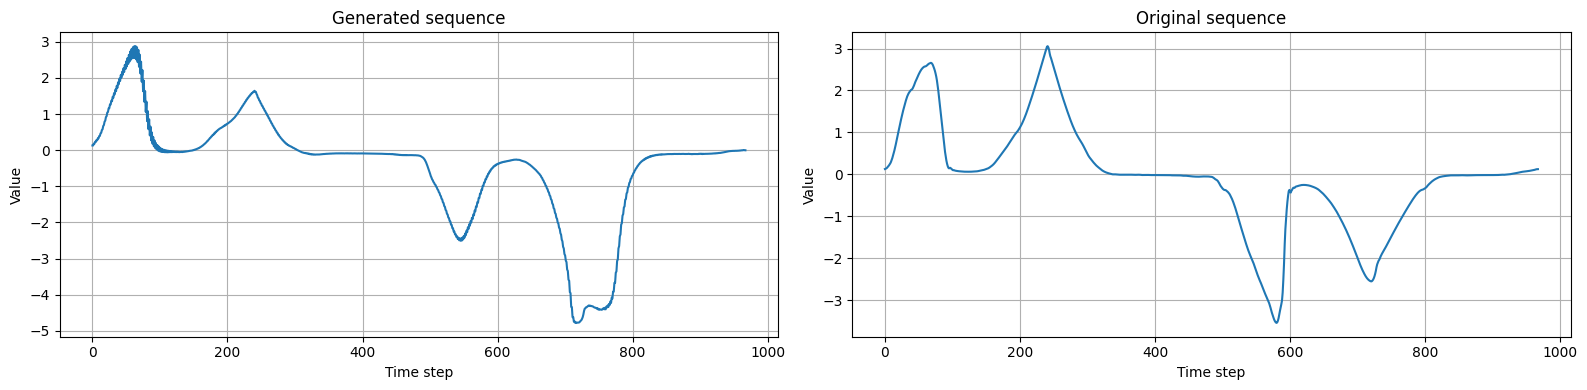

In [11]:
generated_seq = vae.generate(test_dataset[1]['features'].unsqueeze(0).to(device)).squeeze(0).cpu().numpy()  # [968]
test_seq = test_dataset[1]['vah'].cpu().numpy()

fig, axs = plt.subplots(1, 2, figsize=(16, 4))

axs[0].plot(generated_seq)
axs[0].set_title("Generated sequence")
axs[0].set_xlabel("Time step")
axs[0].set_ylabel("Value")
axs[0].grid(True)

axs[1].plot(test_seq)
axs[1].set_title("Original sequence")
axs[1].set_xlabel("Time step")
axs[1].set_ylabel("Value")
axs[1].grid(True)

plt.tight_layout()
plt.show()

In [124]:
torch.save(vae.state_dict(), 'gpt_12dim_2l.pth')